In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib


In [2]:
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test  = pd.read_csv("y_test.csv").values.ravel()

print(X_train.shape, X_test.shape)


(1584, 10) (396, 10)


In [3]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    return mae, rmse, r2


In [4]:
#regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_mae, lr_rmse, lr_r2 = evaluate_model(lr, X_test, y_test)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)


Linear Regression
MAE : 1.1970054937883956
RMSE: 1.3855707282943208
R²  : 0.04335146975707238


In [5]:
#random
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_mae, rf_rmse, rf_r2 = evaluate_model(rf, X_test, y_test)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)


Random Forest
MAE : 1.1794454043573448
RMSE: 1.3684360408670477
R²  : 0.0668659941316383


In [6]:
#gradiant boost
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_mae, gbr_rmse, gbr_r2 = evaluate_model(gbr, X_test, y_test)

print("Gradient Boosting")
print("MAE :", gbr_mae)
print("RMSE:", gbr_rmse)
print("R²  :", gbr_r2)


Gradient Boosting
MAE : 1.2101098880920447
RMSE: 1.412786751496114
R²  : 0.005400500801385766


In [7]:
#comparing
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE":  [lr_mae, rf_mae, gbr_mae],
    "RMSE": [lr_rmse, rf_rmse, gbr_rmse],
    "R2":   [lr_r2, rf_r2, gbr_r2]
})

results.sort_values(by="RMSE")


,Model,MAE,RMSE,R2
1,Random Forest,1.179445,1.368436,0.066866
0,Linear Regression,1.197005,1.385571,0.043351
2,Gradient Boosting,1.210110,1.412787,0.005401


In [8]:
best_model = gbr   # Change if RF performs better

joblib.dump(best_model, "sales_forecast_model.pkl")
print("Best model saved successfully!")


Best model saved successfully!


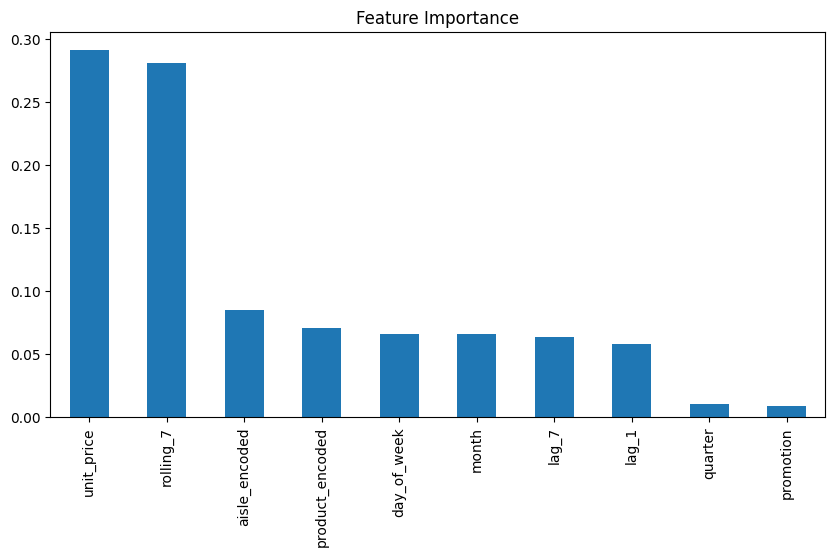

In [9]:
#features importance 
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()
